# Preprocessing

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split


import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, words
import string
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import wordnet
import re
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('words')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\janne\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\janne\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\janne\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\janne\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\janne\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [46]:
df = pd.read_csv(r'..\data\booking_reviews_cleaned.csv')
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,Leisure trip,Couple,Stayed 1 night
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,Leisure trip,Couple,Stayed 6 nights
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,2019,September,Autumn,Business trip,Solo traveller,Stayed 4 nights
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,Leisure trip,People with friends,Stayed 4 nights


In [47]:
df.shape

(26056, 12)

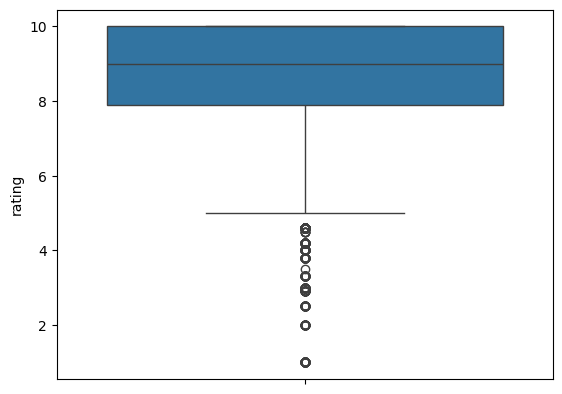

In [48]:
# create label
sns.boxplot(data=df, y='rating')
plt.show()

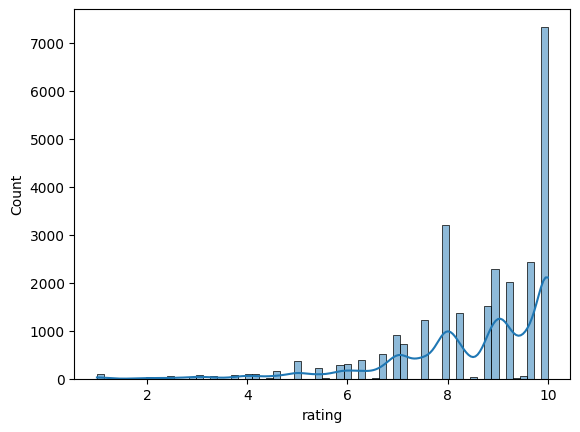

In [49]:
sns.histplot(data=df, x='rating', kde=True)
plt.show()

In [50]:
df['label'] = (df['rating'] > 6.5).astype(int)
df['label'].value_counts()

label
1    23629
0     2427
Name: count, dtype: int64

In [ ]:
# df = df[df['rating'] > 5]

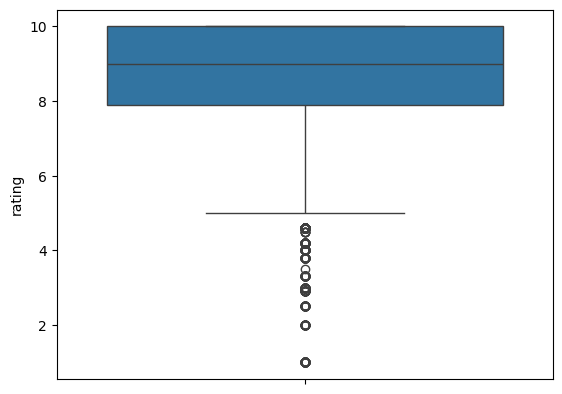

In [51]:
# create label
sns.boxplot(data=df, y='rating')
plt.show()

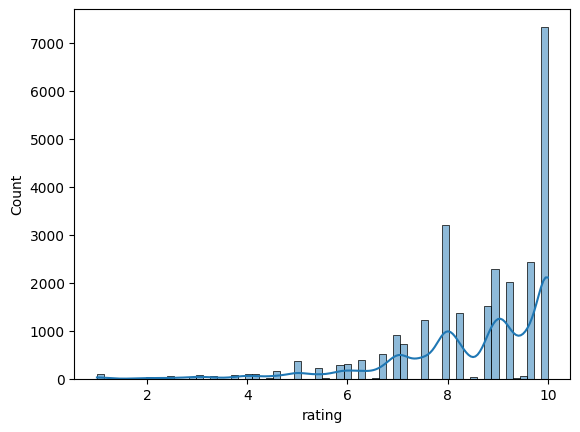

In [52]:
sns.histplot(data=df, x='rating', kde=True)
plt.show()

In [57]:
df['label'] = (df['rating'] > 7).astype(int)
df['label'].value_counts()

label
1    22218
0     3838
Name: count, dtype: int64

In [58]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length,label
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night,1
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,Leisure trip,Couple,Stayed 1 night,1
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,Leisure trip,Couple,Stayed 6 nights,1
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,2019,September,Autumn,Business trip,Solo traveller,Stayed 4 nights,1
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,Leisure trip,People with friends,Stayed 4 nights,1


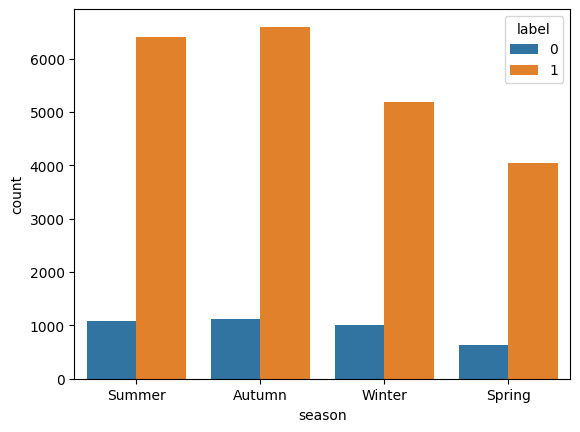

In [59]:
sns.countplot(data=df, x='season', hue='label')
plt.show()

In [60]:
df['label'].value_counts()

label
1    22218
0     3838
Name: count, dtype: int64

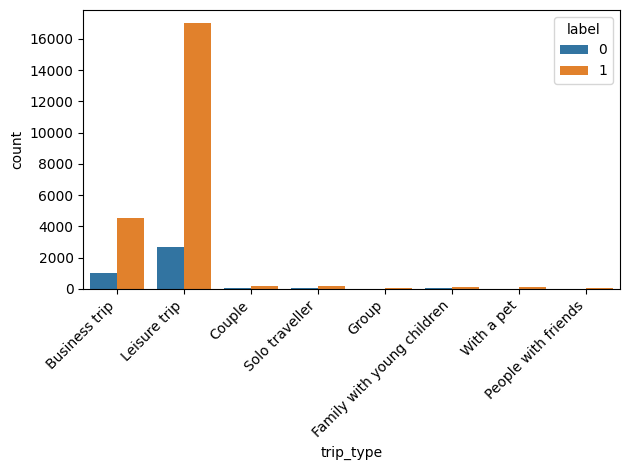

In [61]:
sns.countplot(data=df, x='trip_type', hue='label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
counts = df['traveller_type'].value_counts()
counts[counts > 5].to_frame()

,count
traveller_type,
Couple,8880
Solo traveller,6544
Family with young children,4579
Group,2707
People with friends,1353
Leisure trip,115
Standard Double Room,56
Double Room,39
Standard Double or Twin Room,30


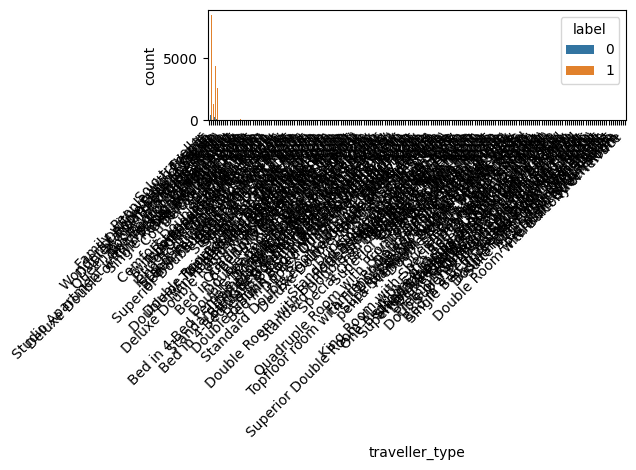

In [26]:
sns.countplot(data=df, x='traveller_type', hue='label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
data.owner=data.owner.replace(to_replace=['no', 'yes'], value=[0, 1])
data.selfemp=data.selfemp.replace(to_replace=['no', 'yes'], value=[0, 1])

data.card=data.card.replace(to_replace=['no', 'yes'], value=[0, 1])
data.card=data.card.astype(bool)
data.head(15)

In [ ]:
pd.read_csv('diabetes.csv')

In [ ]:
pima['label'].value_counts()

In [ ]:
print("label 0 percentage: ", round(500/768,3))
print("label 1 percentage: ", round(268/768,3))

In [ ]:
sns.countplot(x = pima['label'])
plt.show()

In [ ]:
X_train_str, X_test_str, y_train_str, y_test_str = train_test_split(X, y, random_state=0, stratify=y)

In [ ]:
#Initiate Model
model_str = LogisticRegression(max_iter = 1_000_000)
model_str.fit(X_train_str, y_train_str)
y_pred_str = model_str.predict(X_test_str)

In [ ]:
cnf_matrix_str = confusion_matrix(y_test_str, y_pred_str)
cnf_matrix_str

In [ ]:
class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks,class_names)
plt.yticks(tick_marks,class_names)

#Create Heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_str), annot= True, cmap = "YlGnBu", fmt ="g")
plt.tight_layout()
plt.title("Confusion matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
None

### Model Comparison

In [ ]:
# ROC for all models
plt.plot(fpr, tpr, label= "data 0 - Initial, auc=" +str(auc))
plt.plot(fpr_d, tpr_d, label= "data 1 - Downsampled, auc=" +str(auc_d))
plt.plot(fpr_str, tpr_str, label= "data 2 - Stratified, auc=" +str(auc_str))
plt.plot(fpr_bal, tpr_bal, label= "data 3 - Balanced, auc=" +str(auc_bal))

plt.plot([0,1], [0,1], color = "black", linestyle = '--')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

### ROC Curve

In [ ]:
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr, label= "data 0 - Initial, auc=" +str(auc))
plt.plot([0,1], [0,1], color = "black", linestyle = '--')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()